<a href="https://colab.research.google.com/github/yogasriram2012-hub/high-altitude-anti-drone-SIH/blob/main/detection/detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics kagglehub --quiet

In [ ]:
import kagglehub
path = kagglehub.dataset_download("muki2003/yolo-drone-detection-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yolo-drone-detection-dataset' dataset.
Path to dataset files: /kaggle/input/yolo-drone-detection-dataset


In [ ]:
"""
Run this cell right after the dataset download cell, and BEFORE the
main Day 5 training code. It rewrites data.yaml with correct absolute
paths so YOLO can actually find the images.
"""

import os
import yaml

# Locate data.yaml (same search logic as before)
dataset_root = "/kaggle/input/yolo-drone-detection-dataset"
data_yaml_path = None
for root, dirs, files in os.walk(dataset_root):
    if "data.yaml" in files:
        data_yaml_path = os.path.join(root, "data.yaml")
        break

print("Found data.yaml at:", data_yaml_path)

drone_dataset_dir = os.path.dirname(data_yaml_path)  # the drone_dataset/ folder itself

# Read existing yaml
with open(data_yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print("Before fix:", data_config)

# Overwrite with correct absolute paths
data_config["path"] = drone_dataset_dir
data_config["train"] = os.path.join(drone_dataset_dir, "train")
data_config["val"] = os.path.join(drone_dataset_dir, "valid")

# Kaggle's input folder is read-only, so we write a FIXED copy to a
# writable location instead of overwriting the original
fixed_yaml_path = "/content/data_fixed.yaml"
with open(fixed_yaml_path, "w") as f:
    yaml.dump(data_config, f)

print("\nAfter fix, saved to:", fixed_yaml_path)
with open(fixed_yaml_path) as f:
    print(f.read())

# Use this variable in place of data_yaml_path for training:
data_yaml_path = fixed_yaml_path

Found data.yaml at: /kaggle/input/yolo-drone-detection-dataset/drone_dataset/data.yaml
Before fix: {'names': ['drone'], 'nc': 1, 'path': '/drone_dataset/', 'train': '/drone_dataset/train', 'val': '/drone_dataset/valid'}

After fix, saved to: /content/data_fixed.yaml
names:
- drone
nc: 1
path: /kaggle/input/yolo-drone-detection-dataset/drone_dataset
train: /kaggle/input/yolo-drone-detection-dataset/drone_dataset/train
val: /kaggle/input/yolo-drone-detection-dataset/drone_dataset/valid



In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

def train_drone_model(data_yaml, epochs=25, imgsz=640):
    model = YOLO("yolov8n.pt")
    results = model.train(
        data=data_yaml,
        epochs=epochs,
        imgsz=imgsz,
        batch=16,
        name="drone_detector",
        patience=10
    )
    return model

print("Training YOLOv8 on drone dataset...\n")
model = train_drone_model(data_yaml_path, epochs=25)

Training YOLOv8 on drone dataset...

Ultralytics 8.4.140 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=d

Testing on: /kaggle/input/yolo-drone-detection-dataset/drone_dataset/valid/images/0285.jpg

Detection confidence comparison:
  Clean image:            87.38%
  Foggy/dusty image:      71.37%
  Enhanced (compensated): 87.86%


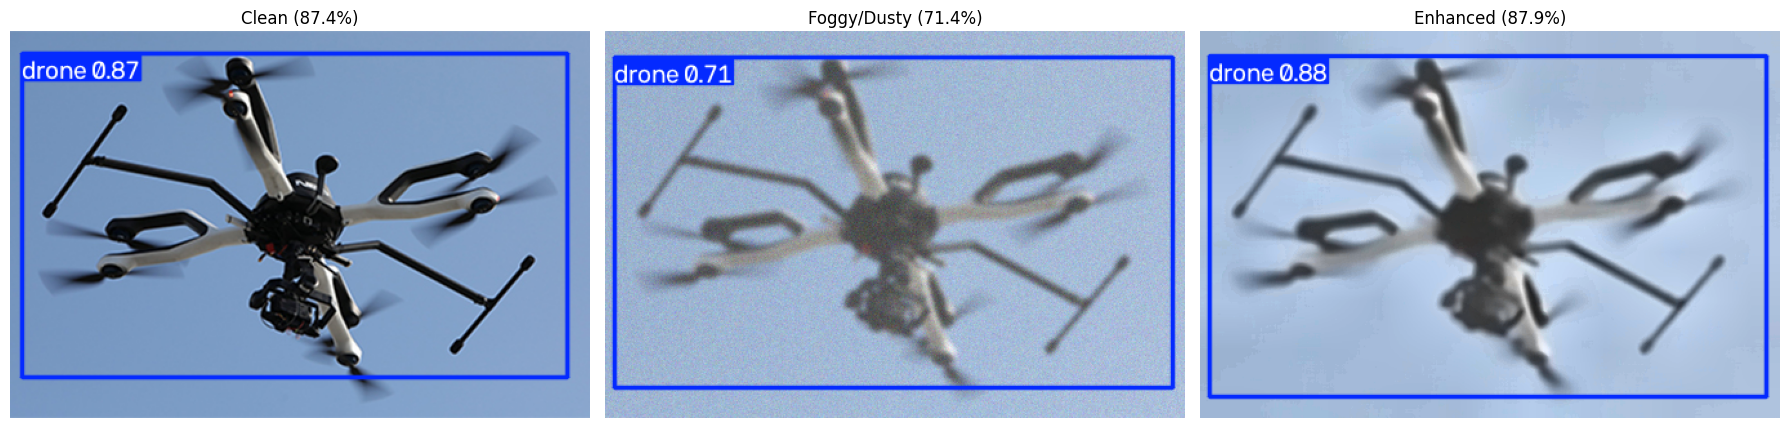


Day 5 complete. File saved: detection_comparison.png


In [ ]:
"""
Day 5 continuation (FIXED) - Test trained model: clean vs foggy/dusty vs enhanced

Fixes from v1:
- Fog/blur/noise severity reduced so detection degrades partially instead
  of failing completely (0% is not a useful demo result)
- Enhancement now denoises FIRST, then applies contrast/sharpening -
  v1 skipped denoising, so CLAHE + sharpen amplified the noise instead
  of cleaning the image up, making the "compensated" image worse than
  the degraded one
"""

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import yaml

trained_model = YOLO("/content/runs/detect/drone_detector-3/weights/best.pt")

with open("/content/data_fixed.yaml") as f:
    cfg = yaml.safe_load(f)
val_dir = os.path.join(cfg["val"], "images")
sample_images = [f for f in os.listdir(val_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
test_image_path = os.path.join(val_dir, sample_images[0])
print("Testing on:", test_image_path)


def apply_dust_fog_effect(image, blur_strength=11, fog_opacity=0.28, noise_std=9):
    """
    Middle ground: v1 (blur=15, fog=0.35, noise=10) erased the drone entirely
    (0% detection). v2 (blur=7, fog=0.18, noise=6) was barely visible at all
    (no meaningful confidence drop). This version aims for a visible but
    survivable degradation - the kind of demo result that actually shows
    something happening.
    """
    blurred = cv2.GaussianBlur(image, (blur_strength, blur_strength), 0)
    fog_layer = np.full_like(blurred, 255)
    foggy = cv2.addWeighted(blurred, 1 - fog_opacity, fog_layer, fog_opacity, 0)
    noise = np.random.normal(0, noise_std, foggy.shape).astype(np.int16)
    noisy = np.clip(foggy.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return noisy


def enhance_visibility(image):
    """
    Fixed order: denoise FIRST (removes the fog-added grain), THEN restore
    contrast with CLAHE, THEN apply a mild sharpen. Applying CLAHE/sharpen
    before denoising (as in v1) amplifies noise instead of removing it.
    """
    denoised = cv2.fastNlMeansDenoisingColored(image, None, h=8, hColor=8,
                                                templateWindowSize=7, searchWindowSize=21)

    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    enhanced_lab = cv2.merge((l_enhanced, a, b))
    enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

    # Mild unsharp mask instead of the aggressive kernel from v1
    gaussian = cv2.GaussianBlur(enhanced, (0, 0), sigmaX=2)
    sharpened = cv2.addWeighted(enhanced, 1.4, gaussian, -0.4, 0)

    return sharpened


def compare_detection_conditions(model, test_image_path):
    original = cv2.imread(test_image_path)
    foggy = apply_dust_fog_effect(original)
    enhanced = enhance_visibility(foggy)

    # Lower confidence threshold so we see partial/weak detections too,
    # not just a binary "detected or not"
    results_clean = model(original, conf=0.15, verbose=False)
    results_foggy = model(foggy, conf=0.15, verbose=False)
    results_enhanced = model(enhanced, conf=0.15, verbose=False)

    def get_top_confidence(results):
        if len(results[0].boxes) == 0:
            return 0.0
        return float(results[0].boxes.conf.max())

    conf_clean = get_top_confidence(results_clean)
    conf_foggy = get_top_confidence(results_foggy)
    conf_enhanced = get_top_confidence(results_enhanced)

    print(f"\nDetection confidence comparison:")
    print(f"  Clean image:            {conf_clean:.2%}")
    print(f"  Foggy/dusty image:      {conf_foggy:.2%}")
    print(f"  Enhanced (compensated): {conf_enhanced:.2%}")

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    titles = [f"Clean ({conf_clean:.1%})", f"Foggy/Dusty ({conf_foggy:.1%})",
              f"Enhanced ({conf_enhanced:.1%})"]
    images = [results_clean[0].plot(), results_foggy[0].plot(), results_enhanced[0].plot()]

    for ax, img, title in zip(axs, images, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("detection_comparison.png", dpi=150)
    plt.show()

    return conf_clean, conf_foggy, conf_enhanced


compare_detection_conditions(trained_model, test_image_path)
print("\nDay 5 complete. File saved: detection_comparison.png")